In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 0: Imports & Configuration
# ══════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Optional, Any

import logging, warnings
for _l in ['matplotlib', 'fontTools', 'PIL']:
    logging.getLogger(_l).setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
mpl.set_loglevel("ERROR")

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# ── Amino acid groupings ──

AMINO_ACIDS_20WAY = [
    'A','C','D','E','F','G','H','I','K','L',
    'M','N','P','Q','R','S','T','V','W','Y'
]

CLASSIFICATION_MODES = {
    '2way': {
        'positive': ['K','R','H'],
        'negative': ['D','E'],
    },
    '3way': {
        'positive': ['K','R','H'],
        'negative': ['D','E'],
        'neutral': ['S','T','N','Q','C','G','A','V','L','I','M','P','F','W','Y'],
    },
    '4way': {
        'positive': ['K','R','H'],
        'negative': ['D','E'],
        'big': ['F','W','Y','L','I','M','V'],
        'small': ['G','A','S','T','C','N','Q','P'],
    },
    '5way_size': {
        'very_small': ['G','A','S'],
        'small': ['C','D','N','P','T','V'],
        'medium': ['E','I','L','Q'],
        'large': ['H','K','M','F'],
        'very_large': ['R','W','Y'],
    },
    'polarity':{
        'nonpolar': ['A', 'G', 'I', 'L', 'M', 'F', 'W', 'P', 'V'],
        'polar': ['S', 'T', 'N', 'Q', 'C', 'Y'],
        'positive': ['K', 'R', 'H'],
        'negative': ['D', 'E']
    },
    
    'biological': {
        'acidic': ['D','E'],
        'basic': ['K','R','H'],
        'polar_uncharged': ['S','T','N','Q','C'],
        'nonpolar_aliphatic': ['G','A','V','L','I','M','P'],
        'aromatic': ['F','W','Y'],
    },
    '20way': {aa: [aa] for aa in AMINO_ACIDS_20WAY},
}

CATEGORY_ORDERS = {
    '2way':      ['positive', 'negative'],
    '3way':      ['positive', 'negative', 'neutral'],
    '4way':      ['positive', 'negative', 'big', 'small'],
    'polarity':  ['nonpolar', 'polar', 'positive', 'negative'],
    '5way_size': ['very_small', 'small', 'medium', 'large', 'very_large'],
    'biological': ['acidic', 'basic', 'polar_uncharged', 'nonpolar_aliphatic', 'aromatic'],
    '20way':     AMINO_ACIDS_20WAY,
}


def get_category(amino_acid: str, mode: str) -> str:
    if mode == '20way':
        return amino_acid
    for cat, aa_list in CLASSIFICATION_MODES[mode].items():
        if amino_acid in aa_list:
            return cat
    raise ValueError(f"{amino_acid} not found in {mode}")



In [2]:
RESULTS_JSON = "/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/20way/results_20way_segment_20260413_111527.json"

def load_results(path: str) -> Dict[str, Any]:
    with open(path, 'r') as f:
        return json.load(f)

results = load_results(RESULTS_JSON)
print(f"Loaded {len(results)} traces")

# Verify scores exist
sample_key = next(iter(results))
sample = results[sample_key]
has_aa_scores = 'aa_scores' in sample and len(sample.get('aa_scores', {})) > 0
has_all_scores = 'all_scores' in sample and len(sample.get('all_scores', {})) > 0

scores_key = 'aa_scores' if has_aa_scores else ('all_scores' if has_all_scores else None)
if scores_key:
    print(f"Using '{scores_key}' for ROC ({len(sample[scores_key])} classes)")
else:
    print("WARNING: No per-AA scores found. ROC plotting unavailable.")
    print(f"  Available keys: {list(sample.keys())}")


Loaded 286 traces
Using 'all_scores' for ROC (20 classes)



── 20-way ROC ──


/tmp/ipykernel_788838/2240401517.py:45: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_20way.pdf


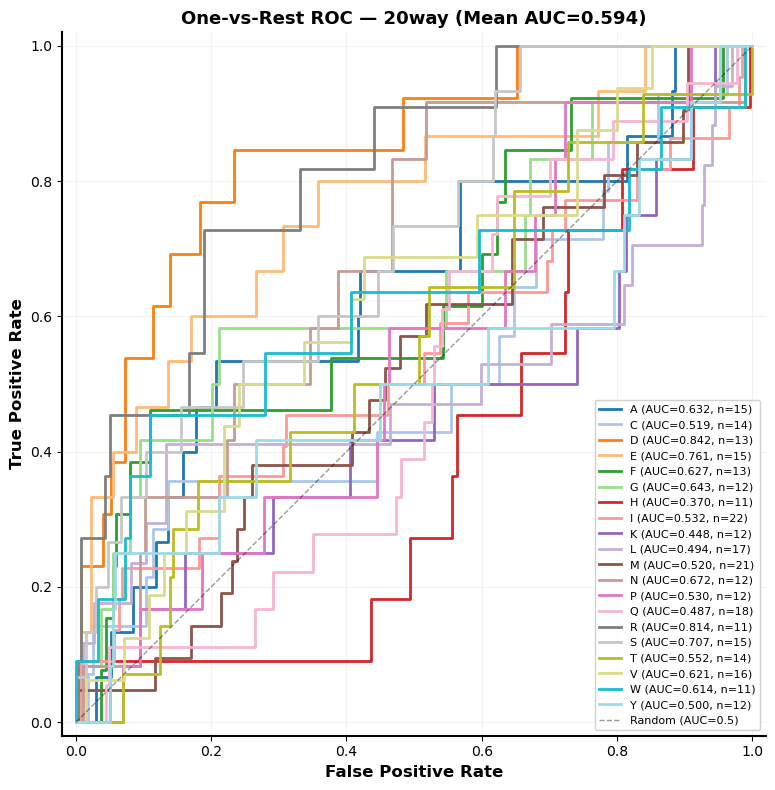


── 4-way ROC ──
  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_5way_size.pdf


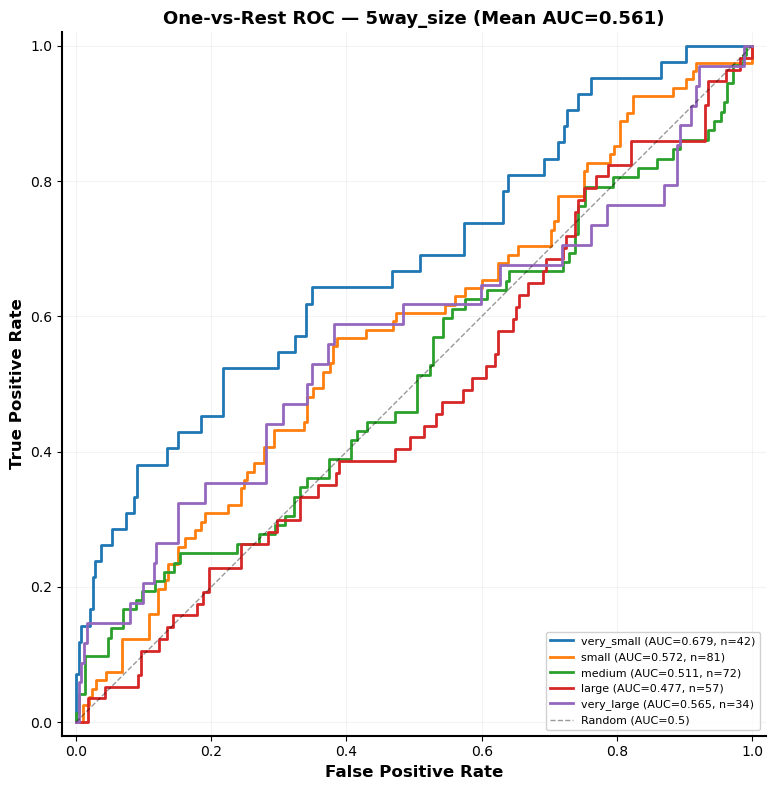


── 2-way ROC ──
  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_polarity.pdf


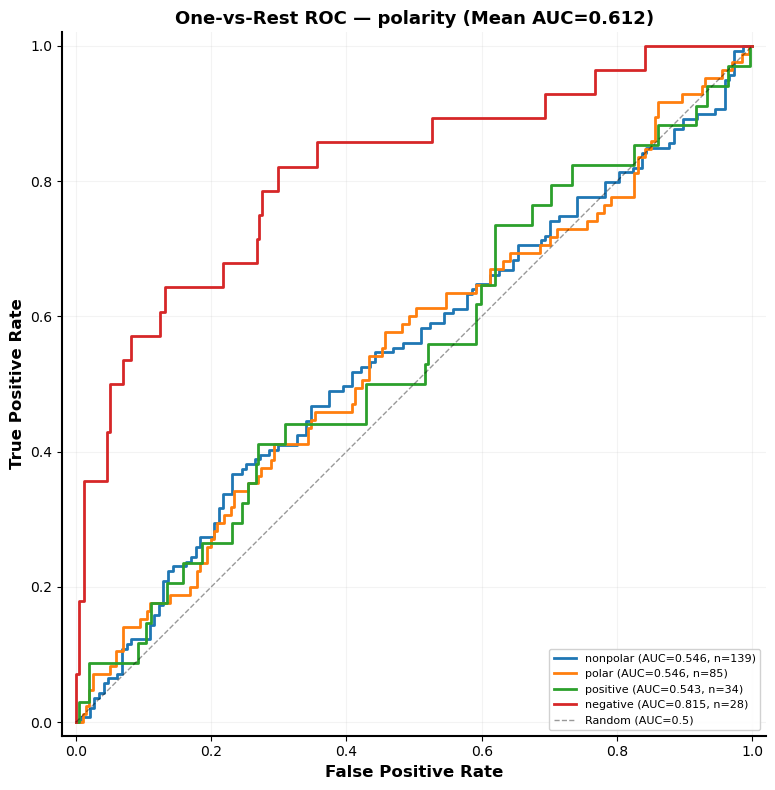


── Biological ROC ──
  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_3way.pdf


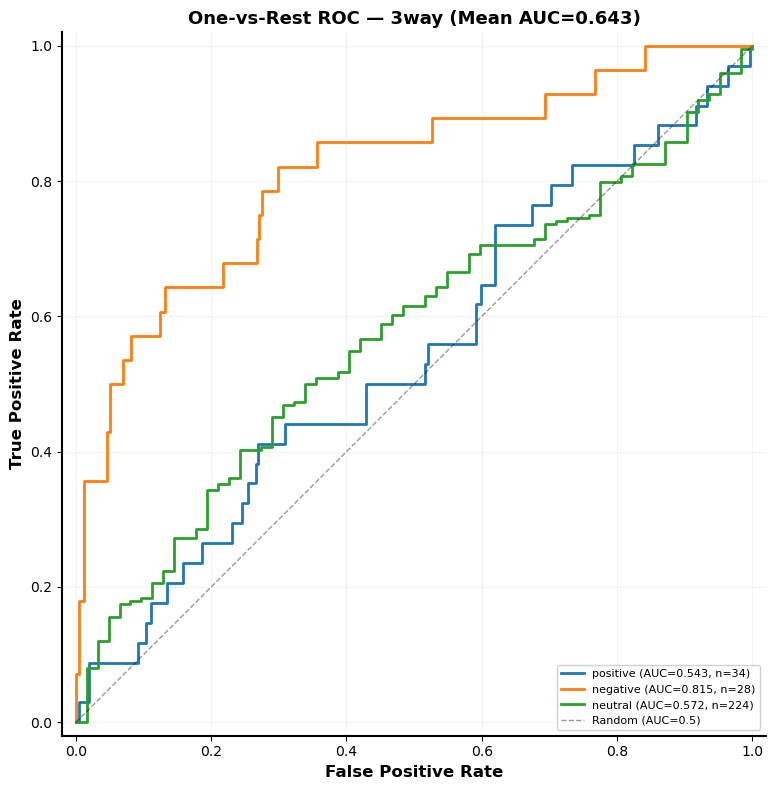


── Biological ROC ──
  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_2way.pdf


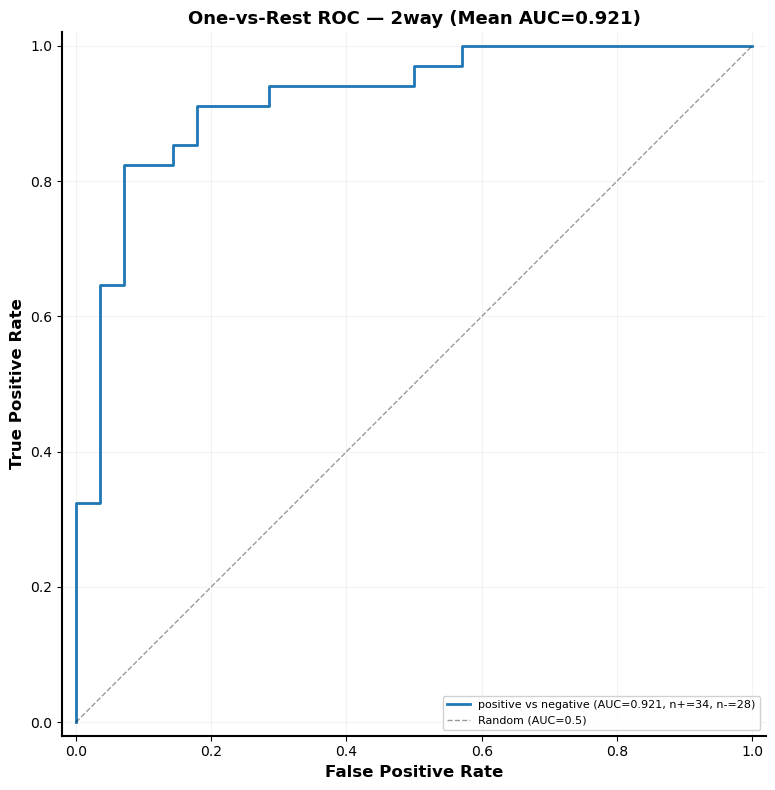

In [3]:

# ══════════════════════════════════════════════════════════════
# CELL 2: ROC Curves
# ══════════════════════════════════════════════════════════════

def compute_roc_curve(y_true: np.ndarray, y_scores: np.ndarray) -> Tuple[np.ndarray, np.ndarray, float]:
    """
    Compute ROC curve (FPR, TPR) and AUC for a single binary problem.
    
    y_true: binary array (1 = positive, 0 = negative)
    y_scores: continuous scores (higher = more likely positive)
    """
    # Sort by decreasing score
    desc_idx = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[desc_idx]
    y_scores_sorted = y_scores[desc_idx]
    
    # Count positives and negatives
    n_pos = np.sum(y_true)
    n_neg = len(y_true) - n_pos
    
    if n_pos == 0 or n_neg == 0:
        return np.array([0, 1]), np.array([0, 1]), 0.5
    
    # Compute TPR and FPR at each threshold
    tpr_list = [0.0]
    fpr_list = [0.0]
    tp = 0
    fp = 0
    
    for i in range(len(y_true_sorted)):
        if y_true_sorted[i] == 1:
            tp += 1
        else:
            fp += 1
        
        # Only add point if score changes or last point
        if i == len(y_true_sorted) - 1 or y_scores_sorted[i] != y_scores_sorted[i + 1]:
            tpr_list.append(tp / n_pos)
            fpr_list.append(fp / n_neg)
    
    fpr = np.array(fpr_list)
    tpr = np.array(tpr_list)
    
    # AUC via trapezoidal rule
    auc = np.trapz(tpr, fpr)
    
    return fpr, tpr, auc


def plot_roc_curves(
    results_dict: Dict[str, Any],
    mode: str = '20way',
    scores_key: str = 'all_scores',
    save_path: Optional[str] = None,
    figsize: Tuple[float, float] = (8, 8),
    title: Optional[str] = None,
) -> Dict[str, float]:
    """
    Plot one-vs-rest ROC curves for each category in the given mode.
    
    For grouped modes (2way, 4way, etc.), per-AA scores are aggregated
    by taking the max score within each category, then ROC is computed
    per category.
    
    Returns dict of {category: AUC}.
    """
    if scores_key is None:
        print("No scores available for ROC plotting.")
        return {}

    category_order = CATEGORY_ORDERS.get(mode, [])
    
    # Build arrays: true categories and score vectors
    true_cats = []
    score_matrix = {}  # {category: list of scores}
    
    for cat in category_order:
        score_matrix[cat] = []
    
    for trace_id, result in results_dict.items():
        true_aa = result.get('amino_acid')
        all_scores = result.get(scores_key, {})
        
        if true_aa is None or not all_scores:
            continue
        
        # Map true AA to category
        try:
            true_cat = get_category(true_aa, mode)
        except ValueError:
            continue
        
        if true_cat not in category_order:
            continue
        
        true_cats.append(true_cat)
        
        # Compute per-category scores
        if mode == '20way':
            for cat in category_order:
                score_matrix[cat].append(all_scores.get(cat, float('-inf')))
        else:
            for cat in category_order:
                aa_list = CLASSIFICATION_MODES[mode][cat]
                cat_scores = [all_scores.get(aa, float('-inf')) for aa in aa_list
                              if aa in all_scores]
                score_matrix[cat].append(max(cat_scores) if cat_scores else float('-inf'))
    
    if not true_cats:
        print("No valid traces found for ROC computation.")
        return {}
    
    true_cats = np.array(true_cats)
    n_cats = len(category_order)
    
    # Use a good colormap
    if n_cats <= 10:
        colors = plt.get_cmap('tab10')(np.linspace(0, 1, 10))[:n_cats]
    else:
        colors = plt.get_cmap('tab20')(np.linspace(0, 1, n_cats))
    
    fig, ax = plt.subplots(figsize=figsize)
    
    auc_dict = {}
    
    # Binary classification: single ROC curve (first category = positive class)
    if len(category_order) == 2:
        pos_cat = category_order[0]
        neg_cat = category_order[1]
        
        y_true = (true_cats == pos_cat).astype(int)
        # Score = P(positive) - P(negative): how much more the model favors positive
        pos_scores = np.array(score_matrix[pos_cat])
        neg_scores = np.array(score_matrix[neg_cat])
        y_scores = pos_scores - neg_scores
        
        fpr, tpr, auc = compute_roc_curve(y_true, y_scores)
        auc_dict[f'{pos_cat}_vs_{neg_cat}'] = auc
        
        n_pos = int(y_true.sum())
        n_neg = len(y_true) - n_pos
        ax.plot(fpr, tpr, color=colors[0], linewidth=2,
                label=f'{pos_cat} vs {neg_cat} (AUC={auc:.3f}, n+={n_pos}, n-={n_neg})')
    
    # Multi-class: one-vs-rest ROC per category
    else:
        for idx, cat in enumerate(category_order):
            y_true = (true_cats == cat).astype(int)
            y_scores = np.array(score_matrix[cat])
            
            # Skip if no positive or no negative examples
            if y_true.sum() == 0 or y_true.sum() == len(y_true):
                print(f"  Skipping {cat}: no positive/negative split")
                continue
            
            fpr, tpr, auc = compute_roc_curve(y_true, y_scores)
            auc_dict[cat] = auc
            
            n_pos = int(y_true.sum())
            ax.plot(fpr, tpr, color=colors[idx], linewidth=2,
                    label=f'{cat} (AUC={auc:.3f}, n={n_pos})')
    
    # Diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.5)')
    
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    
    if title is None:
        mean_auc = np.mean(list(auc_dict.values())) if auc_dict else 0
        title = f'One-vs-Rest ROC — {mode} (Mean AUC={mean_auc:.3f})'
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.15)
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    plt.show()
    plt.close()
    
    return auc_dict


# ── Run ROC curves ──
if scores_key:
    print("\n── 20-way ROC ──")
    auc_20 = plot_roc_curves(results, mode='20way', scores_key=scores_key,
                              save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_20way.pdf")
    
    print("\n── 4-way ROC ──")
    auc_4 = plot_roc_curves(results, mode='5way_size', scores_key=scores_key,
                             save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_5way_size.pdf")
    
    print("\n── 2-way ROC ──")
    auc_2 = plot_roc_curves(results, mode='polarity', scores_key=scores_key,
                             save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_polarity.pdf")
    
    print("\n── Biological ROC ──")
    auc_bio = plot_roc_curves(results, mode='3way', scores_key=scores_key,
                               save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_3way.pdf")

    print("\n── Biological ROC ──")
    auc_bio = plot_roc_curves(results, mode='2way', scores_key=scores_key,
                               save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/plots/roc_2way.pdf")
    

In [4]:

# ══════════════════════════════════════════════════════════════
# CELL 3: Path Statistics
# ══════════════════════════════════════════════════════════════

def parse_path_stats(full_path: List[str]) -> Dict[str, int]:
    """
    Parse a full_path and count all state types.
    
    Returns dict with: n_matches, n_skips, n_backslips, n_self_loops, n_inserts
    """
    stats = {
        'n_matches': 0,
        'n_skips': 0,
        'n_backslips': 0,
        'n_self_loops': 0,
        'n_inserts': 0,
        'n_unique_matches': 0,
        'n_total_path_states': len(full_path),
    }
    
    prev_match_idx = -1
    prev_state = None
    match_indices = []
    
    for state in full_path:
        if state.startswith('Match_'):
            idx = int(state.split('_')[1])
            match_indices.append(idx)
            
            if idx == prev_match_idx and state == prev_state:
                stats['n_self_loops'] += 1
            else:
                stats['n_matches'] += 1
            
            prev_match_idx = idx
            prev_state = state
            
        elif state.startswith('Insert'):
            stats['n_inserts'] += 1
        elif state.startswith('Skip'):
            stats['n_skips'] += 1
        elif state.startswith('Slip'):
            stats['n_backslips'] += 1
    
    stats['n_unique_matches'] = len(set(match_indices))
    
    return stats


def build_path_stats_table(
    results_dict: Dict[str, Any],
    mode: str = '20way',
    save_path: Optional[str] = None,
) -> pd.DataFrame:
    """
    Build a table of average path statistics per class.
    
    Returns DataFrame with one row per category.
    """
    category_order = CATEGORY_ORDERS.get(mode, [])
    
    # Collect stats per category
    cat_stats = defaultdict(list)
    
    for trace_id, result in results_dict.items():
        true_aa = result.get('amino_acid')
        full_path = result.get('full_path', [])
        
        if true_aa is None or not full_path:
            continue
        
        try:
            true_cat = get_category(true_aa, mode)
        except ValueError:
            continue
        
        stats = parse_path_stats(full_path)
        cat_stats[true_cat].append(stats)
    
    # Build table
    rows = []
    stat_keys = ['n_unique_matches', 'n_backslips', 'n_skips',
                 'n_self_loops', 'n_inserts']
    
    for cat in category_order:
        if cat not in cat_stats:
            continue
        
        traces = cat_stats[cat]
        n = len(traces)
        
        row = {'Category': cat, 'n_traces': n}
        
        for key in stat_keys:
            values = [t[key] for t in traces]
            row[f'{key}_mean'] = np.mean(values)
            row[f'{key}_std'] = np.std(values)
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Print formatted table
    print(f"\n{'='*90}")
    print(f"  PATH STATISTICS PER CLASS — {mode}")
    print(f"{'='*90}")
    
    header = f"{'Category':<22} {'n':>4}  {'Unique Matches':>10} {'Backslips':>10} {'Skips':>10} {'Self-loops':>10} {'Inserts':>10}"
    print(header)
    print('-' * len(header))
    
    for _, row in df.iterrows():
        line = (f"{row['Category']:<22} {row['n_traces']:>4}  "
                f"{row['n_unique_matches_mean']:>5.1f}±{row['n_unique_matches_std']:<4.1f}"
                f"{row['n_backslips_mean']:>5.2f}±{row['n_backslips_std']:<4.2f}"
                f"{row['n_skips_mean']:>5.2f}±{row['n_skips_std']:<4.2f}"
                f"{row['n_self_loops_mean']:>5.2f}±{row['n_self_loops_std']:<4.2f}"
                f"{row['n_inserts_mean']:>5.2f}±{row['n_inserts_std']:<4.2f}")
        print(line)
    
    print(f"{'='*90}")
    
    if save_path:
        df.to_csv(save_path, index=False)
        print(f"  Saved: {save_path}")
    
    return df

# ── Run path stats ──
print("\n── Per-AA path statistics ──")
df_20way = build_path_stats_table(results, mode='2way',
                                   save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_2way.csv")

print("\n── Per-category path statistics (4-way) ──")
df_4way = build_path_stats_table(results, mode='3way',
                                  save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_3way.csv")

print("\n── Per-category path statistics (biological) ──")
df_bio = build_path_stats_table(results, mode='polarity',
                                 save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_polarity.csv")


df_polar = build_path_stats_table(results, mode='5way_size',
                                 save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_5way_size.csv")

df_polar = build_path_stats_table(results, mode='20way',
                                 save_path="/projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_20way.csv")



── Per-AA path statistics ──

  PATH STATISTICS PER CLASS — 2way
Category                  n  Unique Matches  Backslips      Skips Self-loops    Inserts
---------------------------------------------------------------------------------------
positive                 34   28.8±5.6  2.29±3.44 6.24±2.14 0.15±0.43 1.65±1.33
negative                 28   27.7±4.0  2.82±2.67 8.54±2.99 0.07±0.26 2.11±1.42
  Saved: /projects/Genometechlab/andrew/protein/nano-protein-signal/hmm/vrhmm/results/04_13_26_ALL_IQR_TRACES_35_SEGS/tables/path_stats_2way.csv

── Per-category path statistics (4-way) ──

  PATH STATISTICS PER CLASS — 3way
Category                  n  Unique Matches  Backslips      Skips Self-loops    Inserts
---------------------------------------------------------------------------------------
positive                 34   28.8±5.6  2.29±3.44 6.24±2.14 0.15±0.43 1.65±1.33
negative                 28   27.7±4.0  2.82±2.67 8.54±2.99 0.07±0.26 2.11±1.42
neutral                 224   29.3±4.

In [9]:
# ══════════════════════════════════════════════════════════════
# CELL 4: Find Clean Backslip Traces
# ══════════════════════════════════════════════════════════════

def find_clean_backslip_traces(
    results_dict: Dict[str, Any],
    min_backslips: int = 2,
    max_skips: int = 1,
    amino_acid: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """
    Find traces with multiple slips (backslips) but minimal skips.
    
    Criteria:
      - At least `min_backslips` Slip states in the path
      - At most `max_skips` Skip states in the path
    
    Returns list of dicts with trace info, sorted by slip count descending.
    """
    candidates = []
    
    for trace_id, result in results_dict.items():
        true_aa = result.get('amino_acid', '?')
        
        if amino_acid and true_aa != amino_acid:
            continue
        
        full_path = result.get('full_path', [])
        if not full_path:
            continue
        
        stats = parse_path_stats(full_path)
        
        if (stats['n_backslips'] >= min_backslips and
            stats['n_skips'] <= max_skips):
            
            candidates.append({
                'trace_id': trace_id,
                'amino_acid': true_aa,
                'predicted': result.get('predicted_category', '?'),
                'log_probability': result.get('log_probability', float('-inf')),
                'n_backslips': stats['n_backslips'],
                'n_skips': stats['n_skips'],
                'n_self_loops': stats['n_self_loops'],
                'n_inserts': stats['n_inserts'],
                'n_matches': stats['n_matches'],
                'n_unique_matches': stats['n_unique_matches'],
            })
    
    # Sort by slip count descending, then log_prob descending
    candidates.sort(key=lambda x: (-x['n_backslips'], -x['log_probability']))
    
    return candidates


# ── Find clean backslip traces ──
print("\n── Clean backslip traces (≥2 slips, ≤1 skip) ──")
clean_backslips = find_clean_backslip_traces(results, min_backslips=2, max_skips=2)

print(f"Found {len(clean_backslips)} clean backslip traces\n")

if clean_backslips:
    header = f"{'Trace ID':<45} {'AA':>3} {'Pred':>5} {'Slips':>5} {'Skips':>5} {'SLP':>5} {'INS':>5} {'M':>4} {'Uniq':>5} {'LogP':>10}"
    print(header)
    print('-' * len(header))
    
    for t in clean_backslips:
        print(f"{t['trace_id']:<45} {t['amino_acid']:>3} {t['predicted']:>5} "
              f"{t['n_backslips']:>5} {t['n_skips']:>5} "
              f"{t['n_self_loops']:>5} {t['n_inserts']:>5} {t['n_matches']:>4} "
              f"{t['n_unique_matches']:>5} {t['log_probability']:>10.2f}")


# ── Per-AA breakdown ──
print("\n── Clean backslip traces per amino acid ──")
aa_counts = defaultdict(int)
for t in clean_backslips:
    aa_counts[t['amino_acid']] += 1

for aa in sorted(aa_counts.keys()):
    print(f"  {aa}: {aa_counts[aa]} traces")


── Clean backslip traces (≥2 slips, ≤1 skip) ──
Found 10 clean backslip traces

Trace ID                                       AA  Pred Slips Skips   SLP   INS    M  Uniq       LogP
-----------------------------------------------------------------------------------------------------
20221122_run02_a_35.0_6009_P                    P     Y    16     0     0     2   33    10     -73.66
20220824_run02_a_469.0_675_H                    H     W    16     2     1     2   32     7    -136.77
20221109_run01_a_497.0_4753_D                   D     F    15     0     0     3   32    11     -55.00
20221122_run03_a_61.0_6877_K                    K     W    15     2     1     0   34     9     -70.08
20220907_run01_a_338.0_2159_G                   G     F    14     0     0     3   32    11     -39.52
20221110_run02_a_8.0_5059_V                     V     W    14     0     1     2   32     9     -51.04
20221220_run04_a_327.0_8515_A                   A     W    14     2     1     2   32     9     -57.26
2